# Predicción de resultados del Mundial 2026

**Objetivo:** construir la base de datos para un modelo de *machine learning* que prediga el resultado de un partido (gana local / empata / gana visitante).

**Fuente de datos:** archivos CSV exportados de [FBref](https://fbref.com/en/comps/), con:
- Resultados partido a partido (`scores*`) de eliminatorias y mundiales 2018, 2022 y 2026.
- Tablas de rendimiento por selección (`eliminatorias*`, `worldcup*`) de cada torneo.

**Estrategia:** entrenar con los partidos de las eliminatorias (2018, 2022, 2026) y los mundiales 2018 y 2022, para **predecir el Mundial 2026**.

---

## ¿Cómo se interpretan los datos inicialmente?

La idea es que el modelo aprenda el patrón "cuando un equipo con cierto nivel enfrenta a otro, ¿quién tiende a ganar?" usando cientos de partidos reales, y luego se aplica a los enfrentamientos del Mundial 2026.

Para que el modelo no adivine resultados al azar, a cada partido se lo describe con estadísticas que ya existían **antes** de jugarse:
- Partidos de un ciclo (eliminatoria + mundial) se describen con el rendimiento de cada selección en **su eliminatoria** de ese ciclo.
- Para el Mundial 2026, usamos el rendimiento de cada selección en la **eliminatoria 2026**.

Así el modelo nunca utiliza datos reales para entrenarse.


## Carga de datasets

Los archivos `.csv` fueron creados por los autores de este cuarderno, debido a la naturaleza en la que los datos fueron encontrados.  
El siguiente bloque realiza la importanción a traves del navegador, para que sea posible cargar archivos de manera mas cómoda.


### Ejemplo de la data obtenida

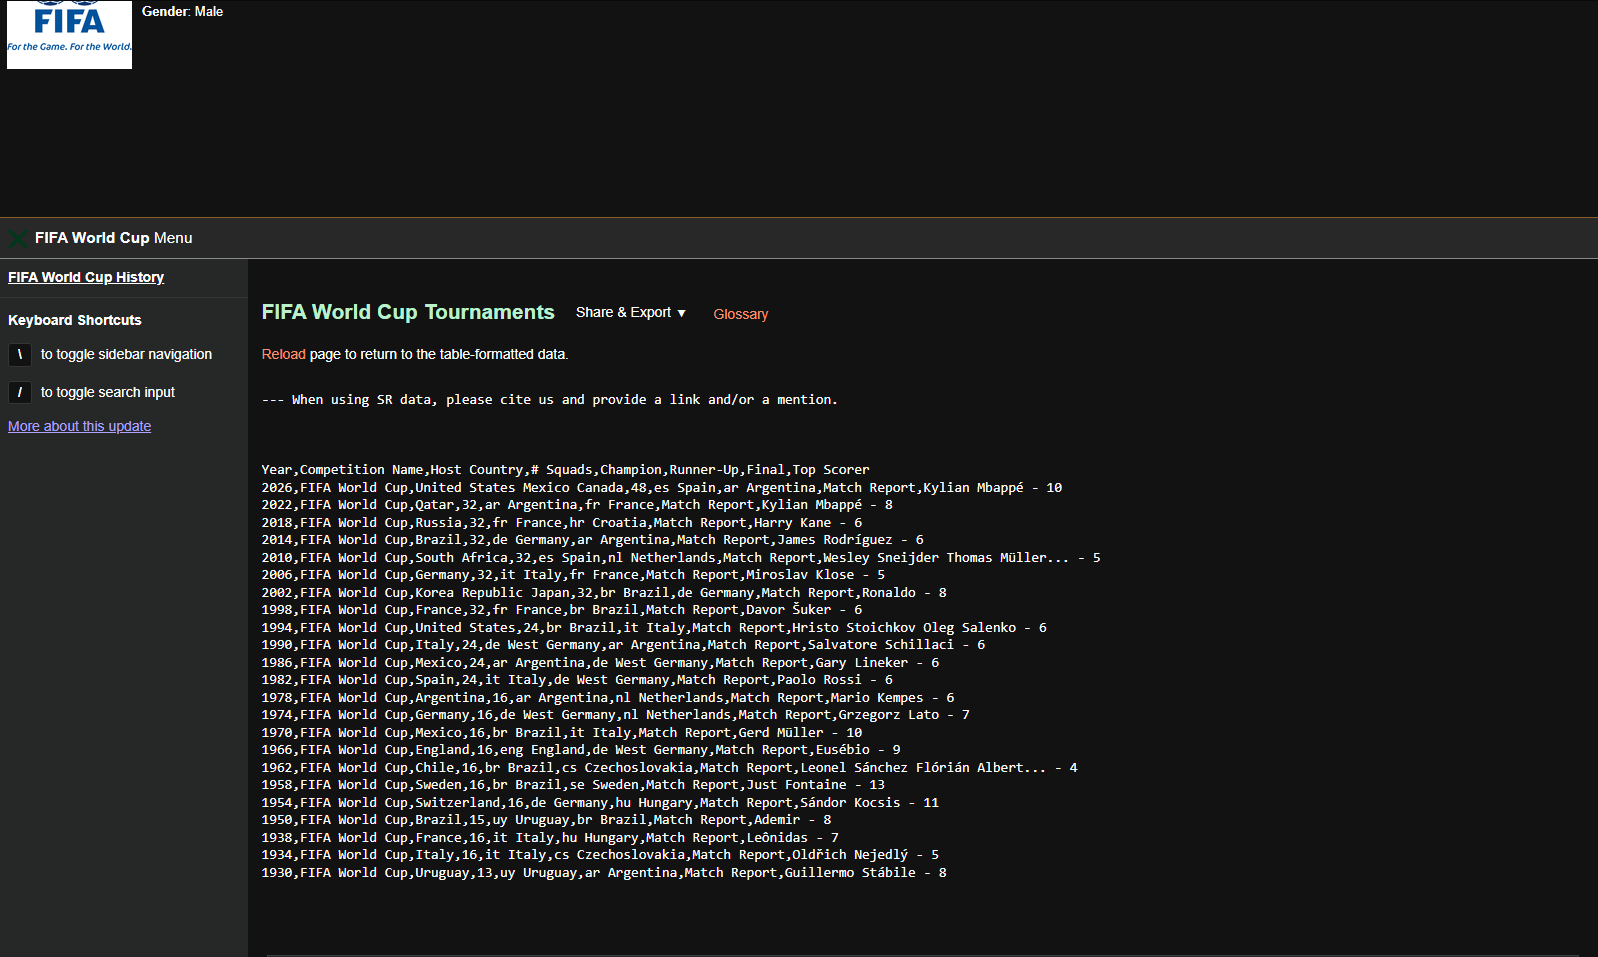

In [ ]:
from google.colab import files

uploaded = files.upload()

## Importar librerías

Usamos `pandas` para manejar los datos y `matplotlib` / `seaborn` para las visualizaciones.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Parte 1: Comprensión y análisis exploratorio preliminar

## 1.1 ¿Qué contiene cada tipo de archivo?

Se obtuvieron tres familias de archivos. Antes de nada, miramos un ejemplo de cada una para entender su contenido.

- **`scores*`**: un partido por fila, con equipos y marcador. Es la base para construir la variable objetivo.
- **`eliminatorias*` / `worldcup*`**: una fila por selección, con su rendimiento agregado en el torneo (goles, posesión, tarjetas, etc.). Serán las características que describen el nivel de cada equipo.
- **`squadShooting*`**: estadísticas de tiro por selección, pero **solo existen para algunos torneos**. Por consistencia entre todas las confederaciones, **no se usan** en este trabajo.

In [ ]:
pd.read_csv('scoresworldcup2022.csv').head()

In [ ]:
pd.read_csv('worldcup2022.csv', header=1).head()

**Interpretación.**
- Los `scores*` traen `Home`, `Score` lo necesario para saber quién ganó.
- Las tablas de selección traen una fila por equipo con columnas como `Gls` (goles), `Poss` (posesión), `CrdY` (tarjetas amarillas), etc. La primera fila del CSV es solo un encabezado de categorías, por eso se la carga con `header=1`.

También notamos dos problemas a corregir más adelante:
1. El guion del marcador aparece como un carácter especial (`–`), no un guion normal.
2. El nombre de cada equipo trae pegado un **código de país** (`ar Argentina`, `Argentina ar`). Ese código será clave para cruzar archivos.

## 1.2 Cargar y unir todos los resultados (sin limpiar)

Juntamos los 36 archivos de `score` de resultados en una sola tabla, **tal cual vienen del CSV**. A cada partido le añadimos de qué **torneo** y **ciclo** proviene.

Guardamos esta versión cruda en `df_scores_raw`: toda la exploración de la Parte 1 se hace sobre ella, para poder comparar más adelante el **antes** y el **después** de la limpieza.

In [ ]:
# Confederaciones y años disponibles
confederations = ['Africa', 'Asia', 'Concacaf', 'Conmebol', 'Oceania', 'UEFA']
years = [2018, 2022, 2026]

score_frames = []

# Resultados de eliminatorias
for year in years:
    for conf in confederations:
        file_name = f'scoresEliminatorias{conf}{year}.csv'
        df = pd.read_csv(file_name)
        df['tournament'] = 'qualifier'
        df['confederation'] = conf
        df['cycle'] = year
        score_frames.append(df)

# Resultados de los mundiales
for year in years:
    file_name = f'scoresworldcup{year}.csv'
    df = pd.read_csv(file_name)
    df['tournament'] = 'worldcup'
    df['confederation'] = 'World'
    df['cycle'] = year
    score_frames.append(df)

df_scores_raw = pd.concat(score_frames, ignore_index=True)
df_scores_raw.head()

## 1.3 Dimensiones, columnas y tipos de datos

Revisamos el tamaño de la tabla de resultados, los nombres de sus columnas y los tipos de datos de cada una.

In [ ]:
print(f'Filas: {df_scores_raw.shape[0]}  |  Columnas: {df_scores_raw.shape[1]}')
print(list(df_scores_raw.columns))

In [ ]:
df_scores_raw.dtypes

**Interpretación.** La tabla reúne todos los partidos. La mayoría de columnas son texto (`object`), incluida `Score`, porque viene como `"6–2"` y aún no es numérica. Columnas como `Attendance`, `Referee`, `Venue`, `Notes` o `Match Report` no aportan al objetivo (quién gana) y se eliminarán en la limpieza.

## 1.4 Valores faltantes y filas vacías

Al exportar de FBref aparecen filas separadoras completamente vacías (sin equipos). Las detectamos contando los valores faltantes por columna.

In [ ]:
df_scores_raw.isnull().sum()

In [ ]:
empty_rows = df_scores_raw['Home'].isnull().sum()
print(f'Filas sin equipo local (vacías): {empty_rows}')

**Interpretación.** Las columnas `Home`, `Away` y `Score` tienen algunos faltantes que corresponden a **filas separadoras vacías** de la exportación. `Attendance` tiene muchos faltantes (no siempre se registra el público), pero esa columna no la usaremos. También hay partidos del Mundial 2026 que aún no se han registrado y por eso no tienen marcador: esos no sirven para entrenar, pero sí son los que querremos predecir.

## 1.5 Registros duplicados

Comprobamos si hay partidos repetidos (misma fecha y mismos equipos). No deberían existir dos veces el mismo partido en una competición.

In [ ]:
duplicates_raw = df_scores_raw.duplicated(subset=['Date', 'Home', 'Away']).sum()
print(f'Filas marcadas como duplicadas en el crudo: {duplicates_raw}')

# partido real vs vacias
dup_mask = df_scores_raw.duplicated(subset=['Date', 'Home', 'Away'], keep=False)
dups = df_scores_raw[dup_mask]
print(f'  - con equipos (partidos reales repetidos): {dups["Home"].notnull().sum()}')
print(f'  - filas vacías repetidas: {dups["Home"].isnull().sum()}')

**Interpretación.** No hay **ningún partido real repetido**, como era de esperar. Los "duplicados" que detecta `duplicated()` son en realidad las **filas separadoras vacías** que FBref intercala al exportar: al estar todas en blanco, pandas las considera iguales entre sí.

Por tanto, estas filas se resolverán al eliminar los vacíos en la limpieza. Se mantendrá igualmente un `drop_duplicates` como red de seguridad, por si en el futuro se añadieran datos con partidos realmente repetidos.

## 1.6 Explorar las tablas de rendimiento por selección

Ahora miramos una tabla de selección para decidir qué columnas describen mejor el nivel de un equipo. Revisamos sus dimensiones, columnas y estadísticas descriptivas.

In [ ]:
df_sample_team = pd.read_csv('eliminatoriasConmebol2026.csv', header=1)
print(f'Filas: {df_sample_team.shape[0]}  |  Columnas: {df_sample_team.shape[1]}')
print(list(df_sample_team.columns))
df_sample_team.head()

In [ ]:
df_sample_team.describe()

**Interpretación y elección de variables.** La tabla tiene muchas columnas, varias redundantes (p. ej. `Gls` aparece como total y como "por 90 minutos"). Para describir el **nivel ofensivo y de disciplina** de cada selección de forma simple y comparable entre torneos, se mantendrá un conjunto reducido:

| Columna | Significado |
|---------|-------------|
| `Gls`   | Goles marcados |
| `Ast`   | Asistencias |
| `CrdY`  | Tarjetas amarillas (indisciplina) |
| `CrdR`  | Tarjetas rojas (indisciplina grave) |
| `MP`    | Partidos jugados (para normalizar por partido) |

Como cada torneo tiene distinta cantidad de partidos, los totales (`Gls`, `Ast`, etc.) se convertirán a **valores por partido** en fases posteriores, para que un equipo que jugó más partidos sea comparable con uno que jugó menos.

# Parte 2: Limpieza y preparación de los datos

A partir de los problemas detectados, aplicamos solo las transformaciones necesarias.

## 2.1 Función para extraer el código de país (estandarización de nombres)

**Problema detectado:** el mismo equipo aparece escrito de formas distintas según el archivo (`ar Argentina`, `Argentina ar`) y algunos nombres cambian entre fuentes (`USA` vs `United States`, `Bosnia–Herz` vs el nombre completo).

**Solución:** cada equipo trae pegado un **código de país** de 2–3 letras que sí es consistente entre todos los archivos. Se extraerán y se usarán como identificador único. Así `ar Argentina`, `Argentina ar` y `ar` se reconocen todos como el mismo equipo (`ar`).

In [ ]:
def extract_country_code(team_name):
    if pd.isnull(team_name):
        return None
    parts = str(team_name).split()
    if not parts:
        return None
    for part in (parts[0], parts[-1]):
        if part.isalpha() and part.islower():
            return part
    return None

## 2.2 Limpiar la tabla de resultados

Se empieza de una **copia** de `df_scores_raw` (para no tocar el crudo) y aplicamos, en orden, solo lo necesario:
1. **Eliminar filas vacías**.
2. **Eliminar duplicados**.
3. **Extraer el código de país** de local y visitante.
4. **Separar el marcador** `"6–2"` en goles de local y visitante.
5. **Convertir la fecha** a tipo fecha.
6. **Eliminar columnas** que no aportan al objetivo.

In [ ]:
df_scores = df_scores_raw.copy()

# Eliminar filas separadoras vacías
df_scores = df_scores.dropna(subset=['Home', 'Away', 'Score'])

# Eliminar duplicados
df_scores = df_scores.drop_duplicates(subset=['Date', 'Home', 'Away'])

# Código de país de cada equipo
df_scores['home_code'] = df_scores['Home'].apply(extract_country_code)
df_scores['away_code'] = df_scores['Away'].apply(extract_country_code)

# Separar el marcador en goles.
score_clean = df_scores['Score'].str.replace('–', '-', regex=False).str.replace('—', '-', regex=False)
goals = score_clean.str.split('-', expand=True)
df_scores['home_goals'] = pd.to_numeric(goals[0], errors='coerce')
df_scores['away_goals'] = pd.to_numeric(goals[1], errors='coerce')

# Fecha a tipo datetime
df_scores['Date'] = pd.to_datetime(df_scores['Date'], errors='coerce')

# Columnas útiles (se eliminan Round, Wk, Day, Time, Attendance, Venue, Referee, Match Report y Notes por no aportar al objetivo)
columns_keep = [
    'Date', 'tournament', 'confederation', 'cycle',
    'home_code', 'away_code', 'home_goals', 'away_goals',
]
df_scores = df_scores[columns_keep].reset_index(drop=True)
df_scores.head()

### Comparación antes -> después de la limpieza

Comprobamos de forma explícita que la limpieza hizo su trabajo: menos filas (se fueron las filas vacías), sin duplicados restantes y con los goles ya convertidos a número.

In [ ]:
print('ANTES (crudo):')
print(f'  Filas: {len(df_scores_raw)}')
print(f'  Filas vacías (sin local): {df_scores_raw["Home"].isnull().sum()}')
print(f'  Duplicados: {duplicates_raw}')

print('\nDESPUÉS (limpio):')
print(f'  Filas: {len(df_scores)}')
duplicates_clean = df_scores.duplicated(subset=['Date', 'home_code', 'away_code']).sum()
print(f'  Duplicados: {duplicates_clean}')
print(f'  Tipo de home_goals: {df_scores["home_goals"].dtype}')
print(f'  Tipo de Date: {df_scores["Date"].dtype}')

### Separar partidos con y sin marcador

El Mundial 2026 está completo (tiene marcador hasta la final), pero algunas eliminatorias listan partidos sin resultado. Un partido sin goles no sirve para entrenar, así que nos quedamos solo con los que tienen marcador.

In [ ]:
# Partidos con marcador = jugados (sirven para construir el dataset)
played = df_scores['home_goals'].notnull() & df_scores['away_goals'].notnull()
df_played = df_scores[played].copy()

print(f'Partidos jugados (con marcador): {len(df_played)}')
print(f'Partidos sin marcador (futuros):  {len(df_scores) - len(df_played)}')

## 2.3 Crear la variable objetivo (resultado)

Definimos `result` desde el punto de vista del equipo local:

| Valor | Significado |
|-------|-------------|
| `2` | Gana el local |
| `1` | Empate |
| `0` | Gana el visitante |

In [ ]:
def match_result(home_goals, away_goals):
    if home_goals > away_goals:
        return 2
    if home_goals == away_goals:
        return 1
    return 0


df_played['result'] = df_played.apply(
    lambda row: match_result(row['home_goals'], row['away_goals']), axis=1
)

df_played['result'].value_counts()

## 2.4 Preparar las estadísticas por selección

### Comprobación: ¿qué columnas están completas en todos los torneos?

Antes de elegir las características definitivas, verificamos la disponibilidad de la **posesión (`Poss`)**, que era una candidata atractiva. Contamos cuántos equipos no tienen ese dato por año de eliminatoria.

In [ ]:
poss_check = []
for year in years:
    for conf in confederations:
        df = pd.read_csv(f'eliminatorias{conf}{year}.csv', header=1)
        poss_check.append({
            'cycle': year,
            'confederation': conf,
            'teams': len(df),
            'poss_missing': df['Poss'].isnull().sum(),
        })

df_poss_check = pd.DataFrame(poss_check)
df_poss_check.groupby('cycle')[['teams', 'poss_missing']].sum()

**Interpretación.** La posesión **falta de forma masiva**: toda la eliminatoria 2018 no la tiene, y en 2022/2026 falta en varias confederaciones. No son errores sueltos sino un hueco sistemático de la fuente.

**Decisión:** Se descarta `Poss` como característica (igual que los datos de tiro). Rellenarla sería inventar demasiados valores y mezclaría torneos con y sin el dato. Se mantiene el modelo con **goles, asistencias y tarjetas por partido**, que sí están completos en todos los torneos. Así el dataset final queda sin valores faltantes de forma natural y sin imputaciones forzadas.

In [ ]:
selected_stats = ['Gls', 'Ast', 'CrdY', 'CrdR', 'MP']


def load_team_table(file_name, tournament, confederation, cycle):

    df = pd.read_csv(file_name, header=1)
    df = df[['Squad'] + selected_stats].copy()

    df['team_code'] = df['Squad'].apply(extract_country_code)

    for col in ['Gls', 'Ast', 'CrdY', 'CrdR']:
        df[f'{col}_per_match'] = df[col] / df['MP']

    df['tournament'] = tournament
    df['confederation'] = confederation
    df['cycle'] = cycle

    keep = ['team_code', 'tournament', 'confederation', 'cycle',
            'Gls_per_match', 'Ast_per_match', 'CrdY_per_match', 'CrdR_per_match']
    return df[keep]

In [ ]:
team_frames = []

# Tablas de eliminatorias
for year in years:
    for conf in confederations:
        file_name = f'eliminatorias{conf}{year}.csv'
        team_frames.append(load_team_table(file_name, 'qualifier', conf, year))

# Tablas de mundiales
for year in years:
    team_frames.append(load_team_table(f'worldcup{year}.csv', 'worldcup', 'World', year))

df_teams = pd.concat(team_frames, ignore_index=True)
print(f'Filas de estadísticas por selección: {len(df_teams)}')
df_teams.head()

### Elegir las estadísticas que describen a cada equipo en cada ciclo

Para describir a un equipo en un partido usamos su rendimiento en la **eliminatoria** de ese ciclo (información previa al mundial). Se mantiene con las tablas de tipo `qualifier` y, por si un equipo aparece en más de una confederación, promediamos por `team_code` y `cycle`.

In [ ]:
feature_stats = ['Gls_per_match', 'Ast_per_match', 'CrdY_per_match', 'CrdR_per_match']

# Rendimiento de cada equipo en su eliminatoria, por ciclo
df_qualifier_stats = df_teams[df_teams['tournament'] == 'qualifier'].copy()
df_team_strength = (
    df_qualifier_stats
    .groupby(['team_code', 'cycle'], as_index=False)[feature_stats]
    .mean()
)

# Media por confederación y ciclo, para rellenar equipos sin datos de eliminatoria
df_conf_mean = (
    df_qualifier_stats
    .groupby(['confederation', 'cycle'], as_index=False)[feature_stats]
    .mean()
)
df_team_strength.head()

## 2.5 Unir estadísticas de cada equipo a cada partido

Cada partido tiene las estadísticas del equipo local y del visitante, buscándolas por `team_code` y `cycle`. Primero una función que trae las stats de un equipo en un ciclo; si el equipo no tiene datos de eliminatoria (como un anfitrión clasificado automáticamente), rellenamos con la **media de su confederación** en ese ciclo.

In [ ]:
# Diccionarios de búsqueda rápida
strength_lookup = df_team_strength.set_index(['team_code', 'cycle']).to_dict('index')
conf_lookup = df_conf_mean.set_index(['confederation', 'cycle']).to_dict('index')

# Confederación de cada equipo
team_conf_lookup = (
    df_qualifier_stats[['team_code', 'confederation']]
    .drop_duplicates('team_code')
    .set_index('team_code')['confederation']
    .to_dict()
)


def get_team_stats(team_code, cycle):
    if (team_code, cycle) in strength_lookup:
        return strength_lookup[(team_code, cycle)]

    confederation = team_conf_lookup.get(team_code)
    if confederation is not None and (confederation, cycle) in conf_lookup:
        return conf_lookup[(confederation, cycle)]

    return None

In [ ]:
def build_feature_rows(df_matches):

    rows = []
    for _, match in df_matches.iterrows():
        home_stats = get_team_stats(match['home_code'], match['cycle'])
        away_stats = get_team_stats(match['away_code'], match['cycle'])

        if home_stats is None or away_stats is None:
            continue

        row = {
            'Date': match['Date'],
            'tournament': match['tournament'],
            'cycle': match['cycle'],
            'home_code': match['home_code'],
            'away_code': match['away_code'],
        }
        if 'result' in match:
            row['result'] = match['result']

        for stat in feature_stats:
            row[f'home_{stat}'] = home_stats[stat]
            row[f'away_{stat}'] = away_stats[stat]
            row[f'diff_{stat}'] = home_stats[stat] - away_stats[stat]

        rows.append(row)

    return pd.DataFrame(rows)

### ¿Por qué se agrega las características de "diferencia"?

Además de las estadísticas de cada equipo por separado, calculamos la **diferencia** (local menos visitante) de cada métrica.

Ese número resume de un golpe **cuánto mejor es un equipo que el otro**, que es lo que de verdad decide un partido. En un Mundial casi todos los partidos son en sede neutral (sin ventaja real de localía), así que la diferencia de nivel entre las dos selecciones es más informativa que saber quién figura como "local".

## 2.6 Dataset de entrenamiento

Se construye el dataset con **todos los partidos jugados excepto el Mundial 2026** (eliminatorias 2018/2022/2026 + mundiales 2018/2022). El Mundial 2026 se aparta porque es justo lo que se quiere predecir: si entrara al entrenamiento, el modelo ya habría visto las respuestas.

In [ ]:
# Marca True en los partidos del Mundial 2026 y False en el resto
is_wc_2026 = (df_played['tournament'] == 'worldcup') & (df_played['cycle'] == 2026)

df_train_matches = df_played[~is_wc_2026].copy()

df_train = build_feature_rows(df_train_matches)
print(f'Partidos de entrenamiento con features completas: {len(df_train)}')
df_train.head()

In [ ]:
df_train.isnull().sum()

## 2.7 Dataset del Mundial 2026 (torneo a predecir)

Preparamos de la misma forma los partidos del Mundial 2026, usando las estadísticas de la eliminatoria 2026 de cada selección. Como el Mundial 2026 ya tiene sus resultados reales, guardamos también `result`: así, al modelar, se podrá comparar la predicción contra lo que de verdad ocurrió. Este dataset tiene las mismas columnas de características que el de entrenamiento.

In [ ]:
# Partidos del Mundial 2026
df_wc2026_matches = df_scores[
    (df_scores['tournament'] == 'worldcup') & (df_scores['cycle'] == 2026)
].copy()

# Añadimos el resultado real para poder comparar luego las predicciones del modelo
df_wc2026_matches['result'] = df_wc2026_matches.apply(
    lambda row: match_result(row['home_goals'], row['away_goals']), axis=1
)

df_predict = build_feature_rows(df_wc2026_matches)
print(f'Partidos del Mundial 2026 con features completas: {len(df_predict)}')
df_predict.head()

## 2.8 Datasets finales

Durante el proceso se crearon varias tablas intermedias, pero todo converge en **dos datasets finales**, ambos con las mismas columnas de características:

- **`df_train`**: todos los partidos jugados (eliminatorias + mundiales 2018/2022) para **entrenar**.
- **`df_predict`**: los partidos del Mundial 2026 para **predecir**.

Cada fila es un partido y las columnas son: datos del partido + estadísticas del local + estadísticas del visitante + sus diferencias + el resultado (`result`).

In [ ]:
print('Dimensiones de los datasets finales:')
print(f'  df_train:   {df_train.shape[0]} filas x {df_train.shape[1]} columnas')
print(f'  df_predict: {df_predict.shape[0]} filas x {df_predict.shape[1]} columnas')

print('\nVista del dataset de entrenamiento (df_train):')
df_train.head()

In [ ]:
df_predict.head()

## 2.9 Visualizaciones finales de comprensión

Dos gráficos para entender el dataset ya preparado.

### Distribución de la variable objetivo

Revisar el balance de clases es importante: si una clase domina, el modelo podría inclinarse hacia ella.

In [ ]:
plt.figure(figsize=(7, 4))
sns.countplot(x='result', data=df_train, order=[2, 1, 0])
plt.title('Distribución de resultados en el entrenamiento')
plt.xlabel('Resultado (2 = gana local, 1 = empate, 0 = gana visitante)')
plt.ylabel('Cantidad de partidos')
plt.tight_layout()
plt.show()

### Correlación entre las features de diferencia y el resultado

Esperamos que las diferencias a favor del local correlacionen de forma positiva con la victoria local.

In [ ]:
diff_columns = [f'diff_{s}' for s in feature_stats]
corr = df_train[diff_columns + ['result']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Correlación entre diferencias de nivel y el resultado')
plt.tight_layout()
plt.show()